<a href="https://colab.research.google.com/github/2403a52261-jpg/NLP/blob/main/NLP_Assignment_12_2_2403a52261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'text'])

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())

print(df['label'].value_counts())

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
label
0    4825
1     747
Name: count, dtype: int64


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Dataset loaded successfully.
Dataset shape: (5572, 2)

--- Sample Inspection ---

First 5 rows of the dataset:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Information (columns, non-null counts, dtypes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Descriptive statistics for object columns:
       label                    text
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll c

/tmp/ipykernel_151/2955821504.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_column_name, data=df, palette='viridis')


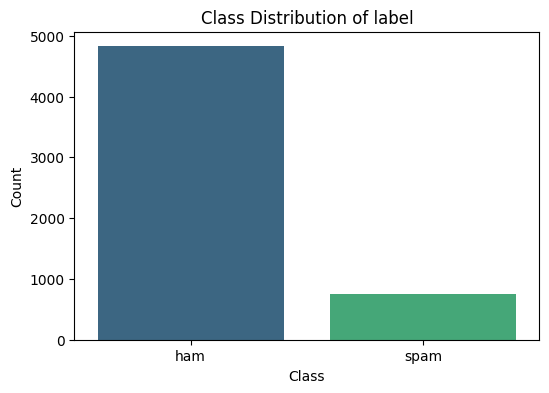


This is important to consider during model training, especially for CNNs.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'text'])
    print("Dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'SMSSpamCollection' not found. Please ensure the dataset file is uploaded or downloaded.")
    print("Creating a dummy DataFrame for demonstration purposes.")
    data_dummy = {
        'text': ['Go until jurong point', 'Ok lar Joking wif u oni', 'Free entry in 2 a wkly comp', 'U dun say so early hor', 'Nah I don\'t think he goes to usf'],
        'label': ['ham', 'ham', 'spam', 'ham', 'ham']
    }
    df = pd.DataFrame(data_dummy)
    print("Dummy DataFrame created.")

print("\n--- Sample Inspection ---")
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Information (columns, non-null counts, dtypes):")
print(df.info())

print("\nDescriptive statistics for object columns:")
print(df.describe(include='object'))

print("\nMissing values per column:")
print(df.isnull().sum())

target_column_name = 'label'

if target_column_name in df.columns:
    print(f"\n--- Class Distribution of '{target_column_name}' ---")
    class_distribution = df[target_column_name].value_counts()
    print(class_distribution)

    print(f"\nClass Distribution (Percentages) of '{target_column_name}':")
    class_percentages = df[target_column_name].value_counts(normalize=True) * 100
    print(class_percentages)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_column_name, data=df, palette='viridis')
    plt.title(f'Class Distribution of {target_column_name}')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

    if len(class_distribution) > 1 and class_percentages.min() < 20:
        print("\nWarning: The dataset appears to have an imbalanced class distribution for the target variable.")
        print("This is important to consider during model training, especially for CNNs.")
else:
    print(f"\nWarning: Target column '{target_column_name}' not found in the dataset. Cannot perform class distribution analysis.")

In [ ]:
import re
import torch

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-z\s]', '', text)

    tokens = text.split()
    return tokens
df['processed_text'] = df['text'].apply(preprocess_text)
print("\n--- Preprocessing Applied ---")
print("First 5 rows with processed text:")
print(df[['text', 'processed_text']].head())

vocab = {'<PAD>': 0, '<UNK>': 1}
for tokens in df['processed_text']:
    for token in tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

print(f"\nVocabulary created with {len(vocab)} unique words.")
print("Sample vocabulary items:", list(vocab.items())[:10])

def encode_sequence(tokens, vocabulary, max_len=50):

    encoded = [vocabulary.get(token, vocabulary['<UNK>']) for token in tokens]
    if len(encoded) < max_len:
        padded_sequence = encoded + [vocabulary['<PAD>']] * (max_len - len(encoded))
    else:
        padded_sequence = encoded[:max_len]
    return padded_sequence

MAX_SEQUENCE_LENGTH = 50
df['encoded_sequence'] = df['processed_text'].apply(lambda x: encode_sequence(x, vocab, MAX_SEQUENCE_LENGTH))

print(f"\nEncoded sequences created with max length {MAX_SEQUENCE_LENGTH}.")
print("First 5 rows with encoded sequences:")
print(df[['processed_text', 'encoded_sequence']].head())

X_encoded = torch.tensor(list(df['encoded_sequence']), dtype=torch.long)



--- Preprocessing Applied ---
First 5 rows with processed text:
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      processed_text  
0  [go, until, jurong, point, crazy, available, o...  
1                     [ok, lar, joking, wif, u, oni]  
2  [free, entry, in, a, wkly, comp, to, win, fa, ...  
3  [u, dun, say, so, early, hor, u, c, already, t...  
4  [nah, i, dont, think, he, goes, to, usf, he, l...  

Vocabulary created with 8631 unique words.
Sample vocabulary items: [('<PAD>', 0), ('<UNK>', 1), ('go', 2), ('until', 3), ('jurong', 4), ('point', 5), ('crazy', 6), ('available', 7), ('only', 8), ('in', 9)]

Encoded sequences created with max length 50.
First 5 rows 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
y_encoded = torch.tensor(df['label_encoded'].values, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n--- Data Splitting Results ---")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(df['label_encoded'].value_counts(normalize=True))

print("\nClass distribution in y_train:")
print(pd.Series(y_train.numpy()).value_counts(normalize=True))

print("\nClass distribution in y_test:")
print(pd.Series(y_test.numpy()).value_counts(normalize=True))



--- Data Splitting Results ---
Shape of X_train: torch.Size([4457, 50])
Shape of X_test: torch.Size([1115, 50])
Shape of y_train: torch.Size([4457])
Shape of y_test: torch.Size([1115])

Class distribution in original data:
label_encoded
0    0.865937
1    0.134063
Name: proportion, dtype: float64

Class distribution in y_train:
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Class distribution in y_test:
0    0.866368
1    0.133632
Name: proportion, dtype: float64


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_classes, kernel_sizes=[3, 4, 5], num_filters=100, dropout_prob=0.5):

        super(TextCNN, self).__init__()


        self.embedding = nn.Embedding(vocab_size + 1, embed_dim)


        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout_prob)


        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):


        x = self.embedding(x)


        x = x.permute(0, 2, 1)

        conv_outputs = []
        for conv in self.convs:

            out = conv(x)

            out = F.relu(out)

            pooled_out = F.max_pool1d(out, out.size(2)).squeeze(2)
            conv_outputs.append(pooled_out)

        concatenated_features = torch.cat(conv_outputs, 1)

        concatenated_features = self.dropout(concatenated_features)


        logits = self.fc(concatenated_features)
        return logits

In [ ]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

vocab_size = len(vocab)
embed_dim = 100
num_classes = len(df['label_encoded'].unique())
kernel_sizes = [3, 4, 5]
num_filters = 100
dropout_prob = 0.5

model = TextCNN(vocab_size, embed_dim, num_classes, kernel_sizes, num_filters, dropout_prob).to(device)


class_counts = df['label_encoded'].value_counts(sort=False)

weight_for_0 = float(sum(class_counts)) / (2.0 * class_counts[0])
weight_for_1 = float(sum(class_counts)) / (2.0 * class_counts[1])
class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = optim.Adam(model.parameters(), lr=0.001)


num_epochs = 10
batch_size = 64


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


training_losses = []

print("\n--- Starting Training ---")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)


        optimizer.zero_grad()


        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)


        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.size(0)


    epoch_loss = total_loss / len(train_loader.dataset)
    training_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("--- Training Complete ---")
print("Training Losses per epoch:", [f'{l:.4f}' for l in training_losses])



Using device: cpu

--- Starting Training ---
Epoch [1/10], Loss: 0.4461
Epoch [2/10], Loss: 0.1696
Epoch [3/10], Loss: 0.0908
Epoch [4/10], Loss: 0.0652
Epoch [5/10], Loss: 0.0366
Epoch [6/10], Loss: 0.0256
Epoch [7/10], Loss: 0.0207
Epoch [8/10], Loss: 0.0174
Epoch [9/10], Loss: 0.0104
Epoch [10/10], Loss: 0.0089
--- Training Complete ---
Training Losses per epoch: ['0.4461', '0.1696', '0.0908', '0.0652', '0.0366', '0.0256', '0.0207', '0.0174', '0.0104', '0.0089']


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader

print("\n--- Starting Model Evaluation ---")

model.eval()

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle test data

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(batch_y.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

accuracy = accuracy_score(all_true_labels, all_predictions)
precision = precision_score(all_true_labels, all_predictions, average='binary')
recall = recall_score(all_true_labels, all_predictions, average='binary')
f1 = f1_score(all_true_labels, all_predictions, average='binary')
conf_matrix = confusion_matrix(all_true_labels, all_predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:\n", conf_matrix)

print("\nClassification Report:\n", classification_report(all_true_labels, all_predictions, target_names=label_encoder.classes_))

print("--- Model Evaluation Complete ---")



--- Starting Model Evaluation ---
Accuracy: 0.9821
Precision: 0.9388
Recall: 0.9262
F1-score: 0.9324

Confusion Matrix:
 [[957   9]
 [ 11 138]]

Classification Report:
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

--- Model Evaluation Complete ---
